In [1]:
#cell 1
import os, json, datetime, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from PIL import Image

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, regularizers, Model
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_fscore_support,
)

warnings.filterwarnings("ignore")

In [2]:
#cell 2
# ── Mount Google Drive ──
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
#cell 3
# ══════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════
CONFIG = {
    #"dataset_path": "/content/drive/MyDrive/updated-dataset",
    #"output_dir": "/content/drive/MyDrive/OUTPUT",
    "dataset_path": "/content/drive/MyDrive/updated-dataset",
    "output_dir": "/content/drive/MyDrive/OUTPUT",
    "image_size": (224, 224),
    "num_channels": 3,
    "num_classes": 5,
    "class_names": [
        "Mild-Demented", "Moderate-Demented", "Non-Demented",
        "Severe-Demented", "Very-Mild-Demented",
    ],
    "batch_size": 32,
    "epochs": 20,
    # "epochs": 100,
    "initial_learning_rate": 1e-3,
    "min_learning_rate": 1e-7,
    "weight_decay": 5e-4,
    "dropout_fc1": 0.5,
    "dropout_fc2": 0.5,
    "label_smoothing": 0.1,
    "early_stopping_patience": 12,
    "reduce_lr_patience": 5,
    "reduce_lr_factor": 0.5,
    "seed": 42,
}

# ══════════════════════════════════════════════════════════════
# UTILITIES
# ══════════════════════════════════════════════════════════════

def set_seeds(seed):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def separator(title):
    print(f"\n{'═'*72}\n  {title}\n{'═'*72}")

In [4]:
#cell 4
# STAGE 1 — DATASET INSPECTION
# ══════════════════════════════════════════════════════════════
#
def inspect_dataset(config):
    separator("STAGE 1 — DATASET INSPECTION")
    base = config["dataset_path"]
    class_names = config["class_names"]
    summary = {}

    for split in ["train", "valid"]:
        split_path = os.path.join(base, split)
        if not os.path.isdir(split_path):
            print(f"  [WARNING] Missing: {split_path}")
            continue

        print(f"\n  Split: {split}")
        print(f"  {'Class':<25} {'Count':>6}  {'%':>8}")
        print(f"  {'-'*42}")

        class_counts = {}
        total = 0
        for cls in class_names:
            cls_path = os.path.join(split_path, cls)
            if not os.path.isdir(cls_path):
                class_counts[cls] = 0
                continue
            files = [f for f in os.listdir(cls_path)
                     if f.lower().endswith(('.jpg','.jpeg','.png'))]
            class_counts[cls] = len(files)
            total += len(files)

        for cls in class_names:
            cnt = class_counts.get(cls, 0)
            pct = (cnt / total * 100) if total > 0 else 0
            print(f"  {cls:<25} {cnt:>6}  {pct:>7.1f}%")
        print(f"  {'TOTAL':<25} {total:>6}")

        summary[split] = {"class_counts": class_counts, "total": total}

    return summary

In [5]:
# cell 5
# ══════════════════════════════════════════════════════════════
# STAGE 2 — EXPLORATORY DATA ANALYSIS
# ══════════════════════════════════════════════════════════════

def perform_eda(config, inspection_summary):
    separator("STAGE 2 — EDA")
    out = os.path.join(config["output_dir"], "eda")
    ensure_dir(out)
    class_names = config["class_names"]
    palette = sns.color_palette("viridis", n_colors=config["num_classes"])

    # Class distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for idx, split in enumerate(["train", "valid"]):
        if split not in inspection_summary:
            continue
        counts = inspection_summary[split]["class_counts"]
        labels, values = list(counts.keys()), list(counts.values())
        bars = axes[idx].bar(labels, values, color=palette, edgecolor="black", linewidth=0.5)
        axes[idx].set_title(f"{split.capitalize()} — Class Distribution", fontsize=13, fontweight="bold")
        axes[idx].set_ylabel("Number of Images")
        axes[idx].tick_params(axis="x", rotation=35)
        for bar, v in zip(bars, values):
            axes[idx].text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
                           str(v), ha="center", va="bottom", fontsize=9, fontweight="bold")
    fig.tight_layout()
    fig.savefig(os.path.join(out, "class_distribution.png"), dpi=150)
    plt.show(); plt.close(fig)

    # Pixel intensity distribution
    pixel_values = {c: [] for c in class_names}
    for cls in class_names:
        cls_dir = os.path.join(config["dataset_path"], "train", cls)
        if not os.path.isdir(cls_dir): continue
        files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        chosen = np.random.choice(files, size=min(40, len(files)), replace=False)
        for f in chosen:
            img = np.array(Image.open(os.path.join(cls_dir, f)).convert("RGB"))
            pixel_values[cls].append(img.mean())

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, cls in enumerate(class_names):
        if pixel_values[cls]:
            ax.hist(pixel_values[cls], bins=25, alpha=0.55, label=cls, color=palette[i])
    ax.set_title("Mean Pixel Intensity Distribution (Train)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Mean Pixel Value (0-255)"); ax.set_ylabel("Frequency")
    ax.legend(fontsize=8); fig.tight_layout()
    fig.savefig(os.path.join(out, "pixel_intensity_distribution.png"), dpi=150)
    plt.show(); plt.close(fig)

    # Sample images grid
    fig, axes = plt.subplots(2, config["num_classes"], figsize=(18, 7))
    for col, cls in enumerate(class_names):
        cls_dir = os.path.join(config["dataset_path"], "train", cls)
        if not os.path.isdir(cls_dir): continue
        files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        chosen = np.random.choice(files, size=min(2, len(files)), replace=False)
        for row, f in enumerate(chosen):
            img = Image.open(os.path.join(cls_dir, f)).convert("RGB")
            axes[row, col].imshow(img); axes[row, col].set_title(cls, fontsize=9)
            axes[row, col].axis("off")
    fig.suptitle("Sample Images per Class (Train)", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    fig.savefig(os.path.join(out, "sample_images.png"), dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)

In [6]:
#cell 6
# ══════════════════════════════════════════════════════════════
# STAGE 3 — DATA LOADING
# ══════════════════════════════════════════════════════════════

def create_data_generators(config):
    separator("STAGE 3 — DATA LOADING")
    base = config["dataset_path"]

    # No augmentation — dataset is already augmented
    datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255.0)

    train_gen = datagen.flow_from_directory(
        os.path.join(base, "train"), target_size=config["image_size"],
        batch_size=config["batch_size"], class_mode="categorical",
        classes=config["class_names"], shuffle=True, seed=config["seed"],
    )
    valid_gen = datagen.flow_from_directory(
        os.path.join(base, "valid"), target_size=config["image_size"],
        batch_size=config["batch_size"], class_mode="categorical",
        classes=config["class_names"], shuffle=False, seed=config["seed"],
    )

    print(f"  Train batches/epoch : {len(train_gen)}")
    print(f"  Valid batches/epoch : {len(valid_gen)}")
    print(f"  Class indices       : {train_gen.class_indices}")
    return train_gen, valid_gen

In [7]:
#cell 7
# ══════════════════════════════════════════════════════════════
# STAGE 4 — MODEL FACTORY (INCEPTION FAMILY - ORDERED)
# ══════════════════════════════════════════════════════════════

def build_model(model_name, config):
    separator(f"BUILDING MODEL: {model_name}")

    img_size = config["image_size"] + (3,)
    num_classes = config["num_classes"]

    # 1️⃣ GoogLeNet (Inception-v1)
    if model_name == "GoogLeNet":
        raise ValueError("GoogLeNet (Inception-v1) not available in tf.keras")

    # 2️⃣ Inception-v2
    elif model_name == "InceptionV2":
        raise ValueError("Inception-v2 not available in tf.keras")

    # 3️⃣ Inception-v3 ✅ (Available)
    elif model_name == "InceptionV3":
        base_model = tf.keras.applications.InceptionV3(
            weights="imagenet",
            include_top=False,
            input_shape=img_size
        )

    # 4️⃣ Inception-v4
    elif model_name == "InceptionV4":
        raise ValueError("Inception-v4 not available in tf.keras")

    # 5️⃣ Inception-ResNet-v2 ✅ (Available)
    elif model_name == "InceptionResNetV2":
        base_model = tf.keras.applications.InceptionResNetV2(
            weights="imagenet",
            include_top=False,
            input_shape=img_size
        )

    else:
        raise ValueError(f"Model {model_name} not supported")

    # Freeze base model
    base_model.trainable = False

    # Custom classification head
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=base_model.input, outputs=outputs, name=model_name)

    model.summary()
    return model

In [8]:

#cell 8
# ══════════════════════════════════════════════════════════════
# STAGE 5 — COMPILE & TRAIN
# ══════════════════════════════════════════════════════════════

def compile_and_train(model, train_gen, valid_gen, config):
    separator("STAGE 5 — TRAINING")
    out = config["output_dir"]
    ensure_dir(out)

    optimizer = optimizers.AdamW(
        learning_rate=config["initial_learning_rate"],
        weight_decay=config["weight_decay"],
    )
    loss_fn = keras.losses.CategoricalCrossentropy(
        label_smoothing=config["label_smoothing"],
    )
    model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])

    # Class weights
    from sklearn.utils.class_weight import compute_class_weight
    cw = compute_class_weight("balanced", classes=np.arange(config["num_classes"]), y=train_gen.classes)
    class_weight_dict = {i: w for i, w in enumerate(cw)}
    print(f"  Class weights: {class_weight_dict}")

    cb_list = [
        callbacks.EarlyStopping(monitor="val_loss", patience=config["early_stopping_patience"],
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=config["reduce_lr_factor"],
                                    patience=config["reduce_lr_patience"],
                                    min_lr=config["min_learning_rate"], verbose=1),
        callbacks.ModelCheckpoint(filepath=os.path.join(out, "best_model.keras"),
                                  monitor="val_loss", save_best_only=True, verbose=1),
        callbacks.CSVLogger(os.path.join(out, "training_log.csv"), separator=",", append=False),
    ]

    print(f"  Optimizer : AdamW (lr={config['initial_learning_rate']}, wd={config['weight_decay']})")
    print(f"  Loss      : CCE (label_smoothing={config['label_smoothing']})")
    print(f"  Epochs    : {config['epochs']} (max), Batch: {config['batch_size']}")

    history = model.fit(
        train_gen, validation_data=valid_gen, epochs=config["epochs"],
        callbacks=cb_list, class_weight=class_weight_dict, verbose=1,
    )
    return history

In [9]:
#cell 9
# ══════════════════════════════════════════════════════════════
# STAGE 6 — EVALUATION
# ══════════════════════════════════════════════════════════════

def evaluate_model(model, valid_gen, config):
    separator("STAGE 6 — EVALUATION")
    class_names = config["class_names"]

    if len(valid_gen) == 0:
        print("  [WARNING] Validation generator is empty. Cannot perform evaluation.")
        empty_results = {
            "test_loss": -1.0, "test_accuracy": -1.0,
            "classification_report": "No validation data available.",
            "confusion_matrix": [],
            "per_class": {},
        }
        for cls in class_names:
            empty_results["per_class"][cls] = {
                "precision": 0.0, "recall": 0.0,
                "f1_score": 0.0, "support": 0,
            }
        return empty_results

    loss, accuracy = model.evaluate(valid_gen, verbose=0)
    print(f"  Test Loss     : {loss:.4f}")
    print(f"  Test Accuracy : {accuracy:.4f}  ({accuracy*100:.2f}%)")

    valid_gen.reset()
    y_pred_proba = model.predict(valid_gen, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = valid_gen.classes

    # Ensure y_true and y_pred have consistent length
    min_len = min(len(y_true), len(y_pred))
    y_true, y_pred = y_true[:min_len], y_pred[:min_len]

    # Handle cases where min_len might still be 0 if valid_gen had samples but predict yielded nothing or very little
    if min_len == 0:
        print("  [WARNING] No predictions or true labels available for evaluation metrics.")
        empty_results = {
            "test_loss": float(loss), "test_accuracy": float(accuracy),
            "classification_report": "No predictions or true labels available.",
            "confusion_matrix": [],
            "per_class": {},
        }
        for cls in class_names:
            empty_results["per_class"][cls] = {
                "precision": 0.0, "recall": 0.0,
                "f1_score": 0.0, "support": 0,
            }
        return empty_results


    report_str = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print(f"\n  Classification Report:\n{report_str}")

    cm = confusion_matrix(y_true, y_pred)
    print(f"  Confusion Matrix:\n{cm}")

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=range(config["num_classes"]))

    results = {
        "test_loss": float(loss), "test_accuracy": float(accuracy),
        "classification_report": report_str, "confusion_matrix": cm.tolist(),
        "per_class": {},
    }
    for i, cls in enumerate(class_names):
        results["per_class"][cls] = {
            "precision": float(precision[i]), "recall": float(recall[i]),
            "f1_score": float(f1[i]), "support": int(support[i]),
        }
    return results

In [10]:
#cell 10
# ══════════════════════════════════════════════════════════════
# STAGE 7 — VISUALIZATION
# ══════════════════════════════════════════════════════════════

def plot_training_curves(history, config):
    separator("STAGE 7 — VISUALIZATION")
    out = os.path.join(config["output_dir"], "plots")
    ensure_dir(out)
    epochs_ran = range(1, len(history.history["loss"]) + 1)

    # Loss curves
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(epochs_ran, history.history["loss"], label="Train Loss", lw=2, color="#3b82f6")
    ax.plot(epochs_ran, history.history["val_loss"], label="Val Loss", lw=2, color="#ef4444", ls="--")
    ax.set_title("Training & Validation Loss", fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend(); ax.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig(os.path.join(out, "loss_curves.png"), dpi=150)
    plt.show(); plt.close(fig)

    # Accuracy curves
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(epochs_ran, history.history["accuracy"], label="Train Acc", lw=2, color="#22c55e")
    ax.plot(epochs_ran, history.history["val_accuracy"], label="Val Acc", lw=2, color="#f97316", ls="--")
    ax.set_title("Training & Validation Accuracy", fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy"); ax.legend(); ax.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig(os.path.join(out, "accuracy_curves.png"), dpi=150)
    plt.show(); plt.close(fig)

    # Combined
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    ax1.plot(epochs_ran, history.history["loss"], label="Train", lw=2, color="#3b82f6")
    ax1.plot(epochs_ran, history.history["val_loss"], label="Val", lw=2, color="#ef4444", ls="--")
    ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(epochs_ran, history.history["accuracy"], label="Train", lw=2, color="#22c55e")
    ax2.plot(epochs_ran, history.history["val_accuracy"], label="Val", lw=2, color="#f97316", ls="--")
    ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.legend(); ax2.grid(alpha=0.3)
    fig.suptitle("AlexNet Training Summary", fontsize=15, fontweight="bold", y=1.02)
    fig.tight_layout()
    fig.savefig(os.path.join(out, "training_summary.png"), dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)


def plot_confusion_matrix(results, config):
    out = os.path.join(config["output_dir"], "plots")
    ensure_dir(out)
    cm = np.array(results["confusion_matrix"])
    class_names = config["class_names"]

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, linecolor="gray", ax=ax)
    ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
    ax.set_ylabel("True Label"); ax.set_xlabel("Predicted Label")
    plt.xticks(rotation=35, ha="right"); plt.yticks(rotation=0)
    fig.tight_layout(); fig.savefig(os.path.join(out, "confusion_matrix.png"), dpi=150)
    plt.show(); plt.close(fig)

    # Normalized
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="YlOrRd",
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, linecolor="gray", ax=ax, vmin=0, vmax=1)
    ax.set_title("Normalized Confusion Matrix", fontsize=14, fontweight="bold")
    ax.set_ylabel("True Label"); ax.set_xlabel("Predicted Label")
    plt.xticks(rotation=35, ha="right"); plt.yticks(rotation=0)
    fig.tight_layout(); fig.savefig(os.path.join(out, "confusion_matrix_normalized.png"), dpi=150)
    plt.show(); plt.close(fig)


In [11]:
#cell 11
# ══════════════════════════════════════════════════════════════
# STAGE 8 — SAVE MODEL & RESULTS
# ══════════════════════════════════════════════════════════════

def save_everything(model, history, results, config):
    separator("STAGE 8 — SAVING ARTEFACTS")
    out = config["output_dir"]
    ensure_dir(out)

    # Full model
    model.save(os.path.join(out, "Googlenet_final.keras"))
    print(f"  ✓ Final model saved")

    # Weights
    model.save_weights(os.path.join(out, "Googlenet_weights.weights.h5"))
    print(f"  ✓ Weights saved")

    # Architecture JSON
    with open(os.path.join(out, "Googlenet_architecture.json"), "w") as f:
        json.dump(json.loads(model.to_json()), f, indent=2)
    print(f"  ✓ Architecture JSON saved")

    # Training history
    hist_data = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    with open(os.path.join(out, "training_history.json"), "w") as f:
        json.dump(hist_data, f, indent=2)
    print(f"  ✓ Training history saved")

    # Evaluation results
    with open(os.path.join(out, "evaluation_results.json"), "w") as f:
        json.dump(results, f, indent=2)
    print(f"  ✓ Evaluation results saved")

    # Config snapshot
    config_safe = {k: v for k, v in config.items()}
    config_safe["timestamp"] = datetime.datetime.now().isoformat()
    with open(os.path.join(out, "config_snapshot.json"), "w") as f:
        json.dump(config_safe, f, indent=2)
    print(f"  ✓ Config snapshot saved")

In [14]:
#cell 12

# ══════════════════════════════════════════════════════════════
# MAIN PIPELINE (SINGLE MODEL TRAINING MODE)
# ══════════════════════════════════════════════════════════════

def main(model_name):
    print("╔══════════════════════════════════════════════════════════════╗")
    print(f"║  TRAINING MODEL: {model_name}")
    print("╚══════════════════════════════════════════════════════════════╝")

    set_seeds(CONFIG["seed"])

    # GPU check
    gpus = tf.config.list_physical_devices("GPU")
    print(f"\nTensorFlow : {tf.__version__}")
    print(f"GPUs       : {len(gpus)}")
    for g in gpus:
        print(f" • {g.name}")

    # Pipeline steps
    inspection = inspect_dataset(CONFIG)
    perform_eda(CONFIG, inspection)
    train_gen, valid_gen = create_data_generators(CONFIG)

    # Build model
    model = build_model(model_name, CONFIG)

    # Train
    history = compile_and_train(model, train_gen, valid_gen, CONFIG)

    # Evaluate
    results = evaluate_model(model, valid_gen, CONFIG)

    # Save
    model.save(f"{CONFIG['output_dir']}/{model_name}.keras")

    # Plots
    plot_training_curves(history, CONFIG)
    plot_confusion_matrix(results, CONFIG)

    print("\n══════════════════════════════")
    print(f"{model_name} Accuracy: {results['test_accuracy']*100:.2f}%")
    print("══════════════════════════════")

╔══════════════════════════════════════════════════════════════╗
║  TRAINING MODEL: InceptionV3
╚══════════════════════════════════════════════════════════════╝

TensorFlow : 2.19.0
GPUs       : 1
 • /physical_device:GPU:0

════════════════════════════════════════════════════════════════════════
  STAGE 1 — DATASET INSPECTION
════════════════════════════════════════════════════════════════════════

  Split: train
  Class                      Count         %
  ------------------------------------------
  Mild-Demented               1000     20.0%
  Moderate-Demented           1000     20.0%
  Non-Demented                1000     20.0%
  Severe-Demented             1000     20.0%
  Very-Mild-Demented          1000     20.0%
  TOTAL                       5000

  Split: valid
  Class                      Count         %
  ------------------------------------------
  Mild-Demented                293     33.7%
  Moderate-Demented            239     27.5%
  Non-Demented                 192   

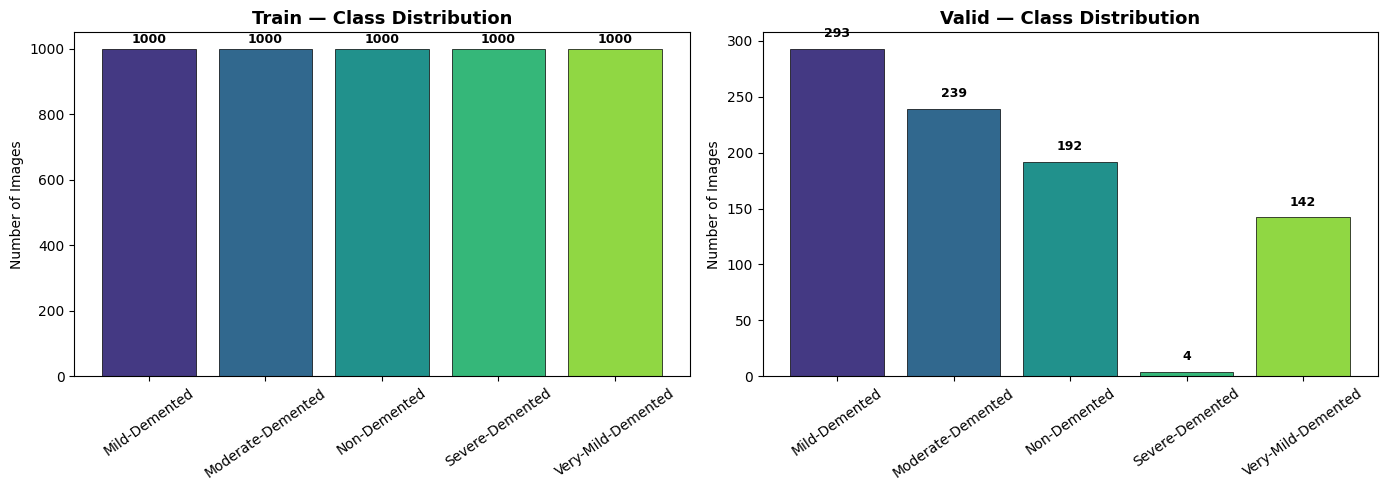

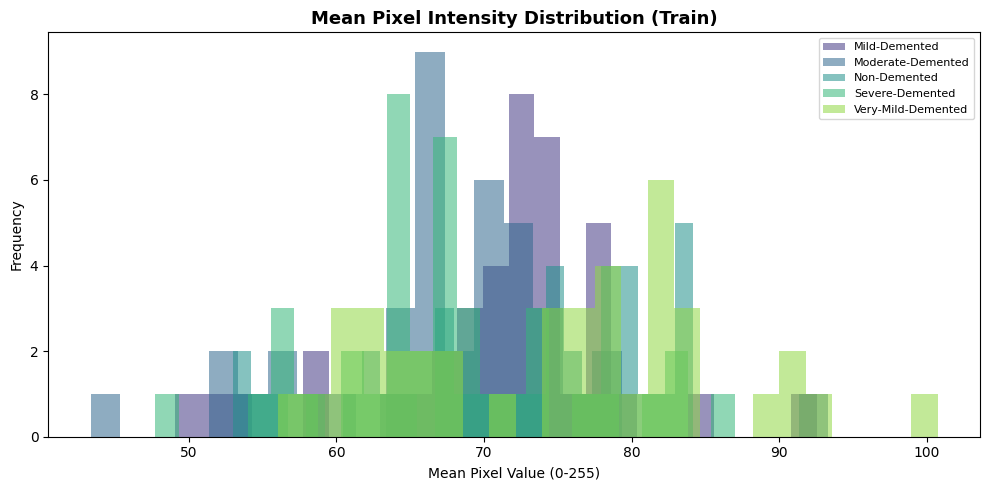

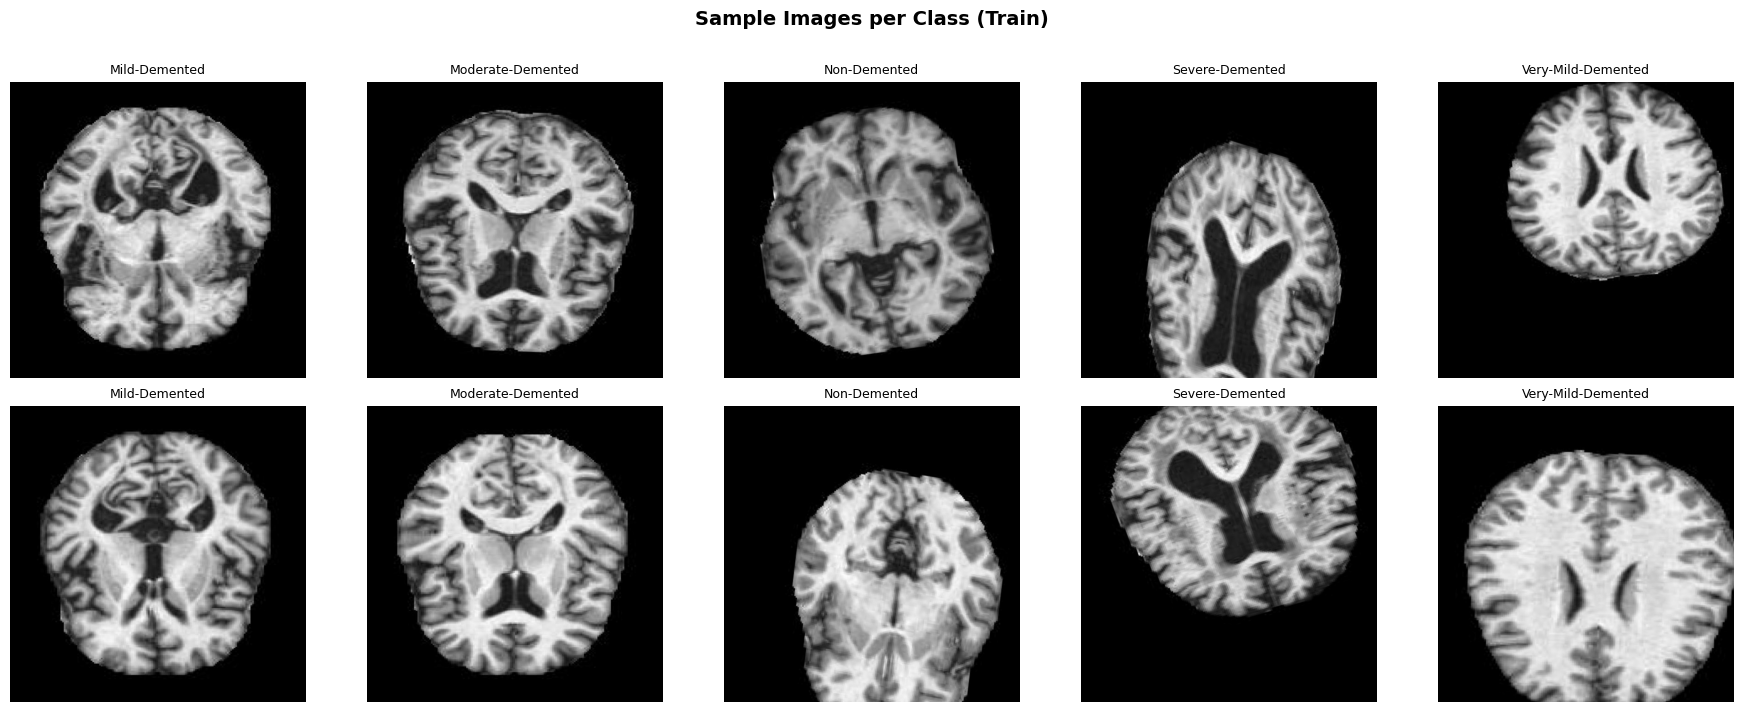


════════════════════════════════════════════════════════════════════════
  STAGE 3 — DATA LOADING
════════════════════════════════════════════════════════════════════════
Found 5000 images belonging to 5 classes.
Found 870 images belonging to 5 classes.
  Train batches/epoch : 157
  Valid batches/epoch : 28
  Class indices       : {'Mild-Demented': 0, 'Moderate-Demented': 1, 'Non-Demented': 2, 'Severe-Demented': 3, 'Very-Mild-Demented': 4}

════════════════════════════════════════════════════════════════════════
  BUILDING MODEL: InceptionV3
════════════════════════════════════════════════════════════════════════


Model: "InceptionV3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_297 (Conv2D) │ (None, 111, 111,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 111, 111,  │         96 │ conv2d_297[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_297      │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_298 (Conv2D) │ (None, 109, 109,  │      9,216 │ activation_297[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_298[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_298      │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_299 (Conv2D) │ (None, 109, 109,  │     18,432 │ activation_298[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_299[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_299      │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 54, 54,    │          0 │ activation_299[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_300 (Conv2D) │ (None, 54, 54,    │      5,120 │ max_pooling2d_8[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_300[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_300      │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_301 (Conv2D) │ (None, 52, 52,    │    138,240 │ activation_300[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_301[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_301      │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 22,862,629 (87.21 MB)

 Trainable params: 1,055,749 (4.03 MB)

 Non-trainable params: 21,806,880 (83.19 MB)


════════════════════════════════════════════════════════════════════════
  STAGE 5 — TRAINING
════════════════════════════════════════════════════════════════════════
  Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}
  Optimizer : AdamW (lr=0.001, wd=0.0005)
  Loss      : CCE (label_smoothing=0.1)
  Epochs    : 20 (max), Batch: 32
Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.7642 - loss: 1.3469
Epoch 1: val_loss improved from None to 0.67402, saving model to /content/drive/MyDrive/OUTPUT/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/OUTPUT/best_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 75s 387ms/step - accuracy: 0.8054 - loss: 1.2036 - val_accuracy: 0.8690 - val_loss: 0.6740 - learning_rate: 0.0010
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.8675 - loss: 0.8634
Epoch 2: val_loss improved from 0.67402 to 0.66082, saving model to /content/drive/M

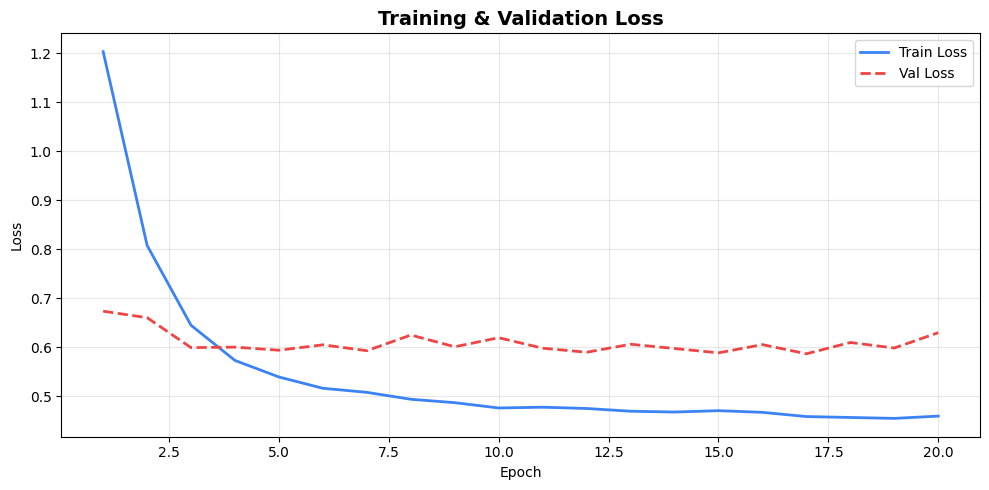

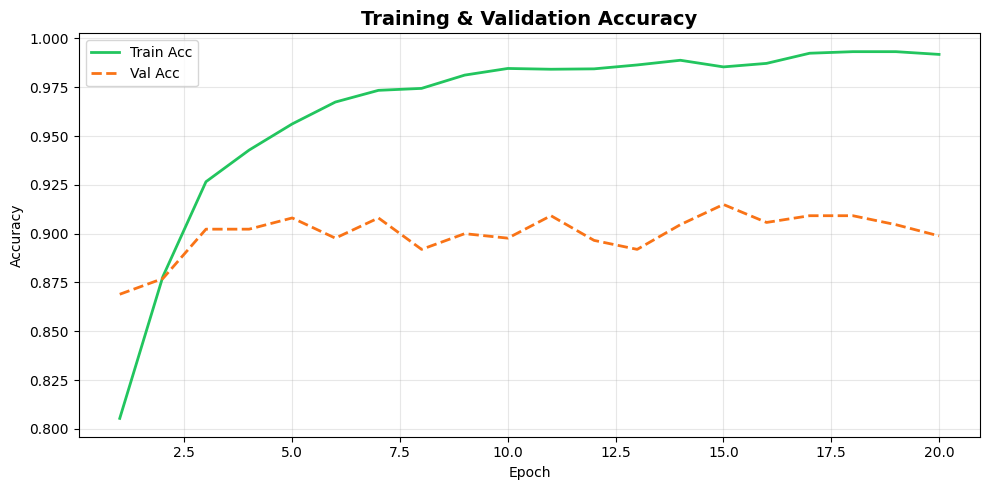

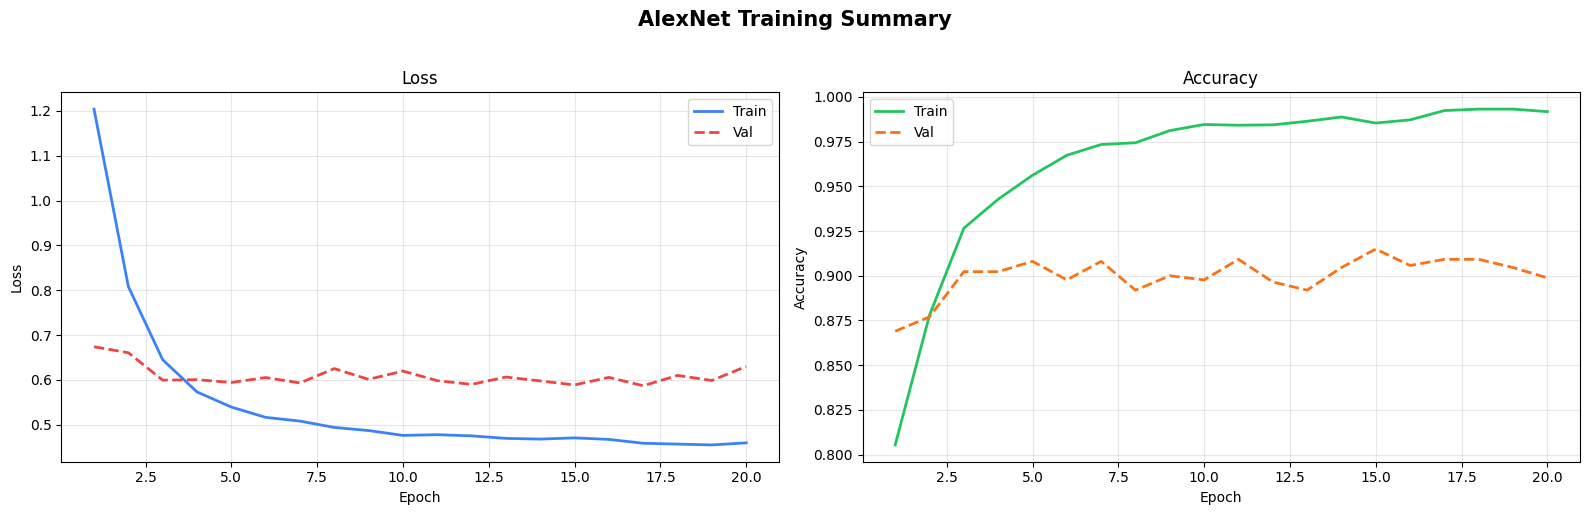

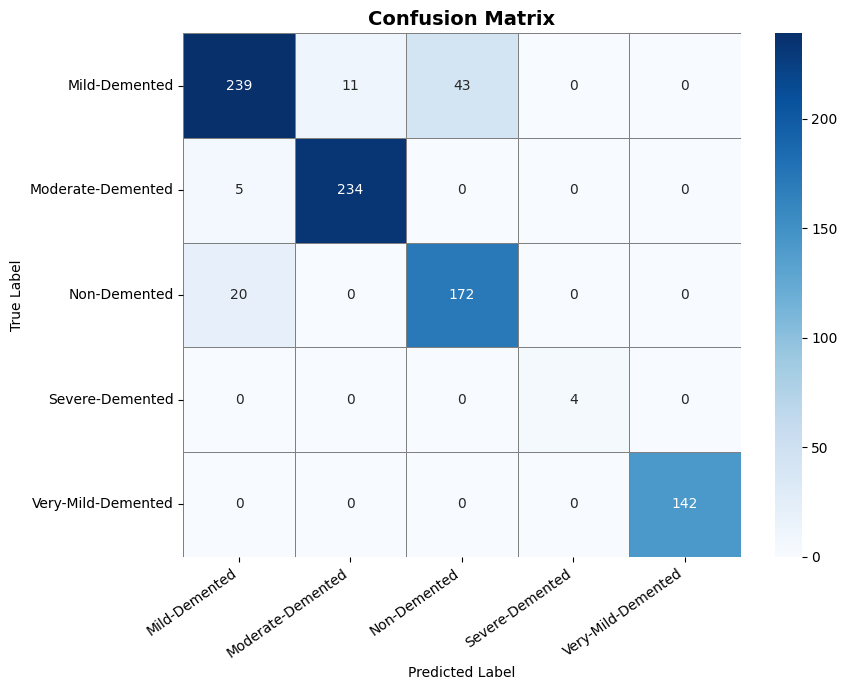

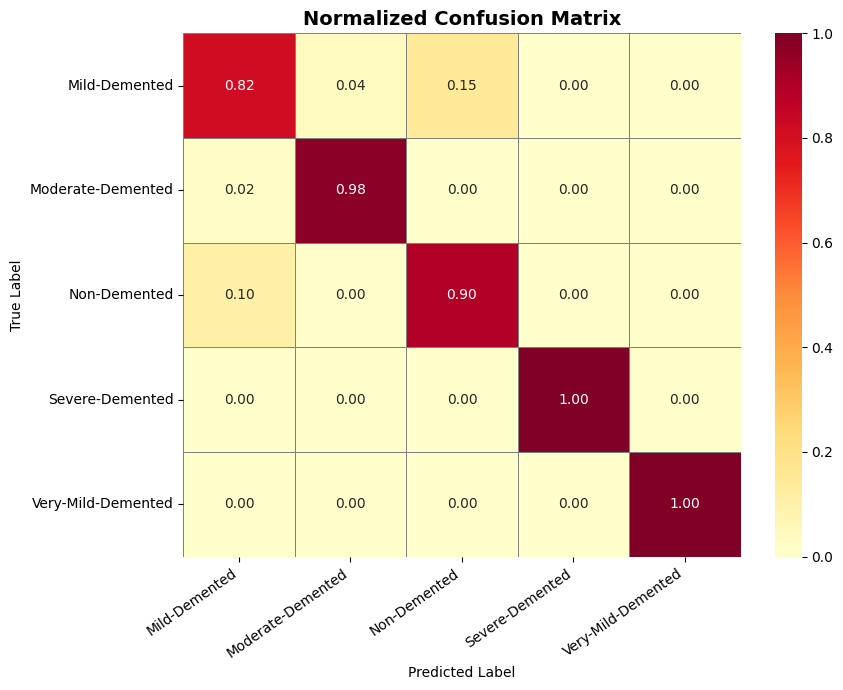


══════════════════════════════
InceptionV3 Accuracy: 90.92%
══════════════════════════════


In [18]:
# cell 13
main("InceptionV3")

╔══════════════════════════════════════════════════════════════╗
║  TRAINING MODEL: InceptionResNetV2
╚══════════════════════════════════════════════════════════════╝

TensorFlow : 2.19.0
GPUs       : 1
 • /physical_device:GPU:0

════════════════════════════════════════════════════════════════════════
  STAGE 1 — DATASET INSPECTION
════════════════════════════════════════════════════════════════════════

  Split: train
  Class                      Count         %
  ------------------------------------------
  Mild-Demented               1000     20.0%
  Moderate-Demented           1000     20.0%
  Non-Demented                1000     20.0%
  Severe-Demented             1000     20.0%
  Very-Mild-Demented          1000     20.0%
  TOTAL                       5000

  Split: valid
  Class                      Count         %
  ------------------------------------------
  Mild-Demented                293     33.7%
  Moderate-Demented            239     27.5%
  Non-Demented                 

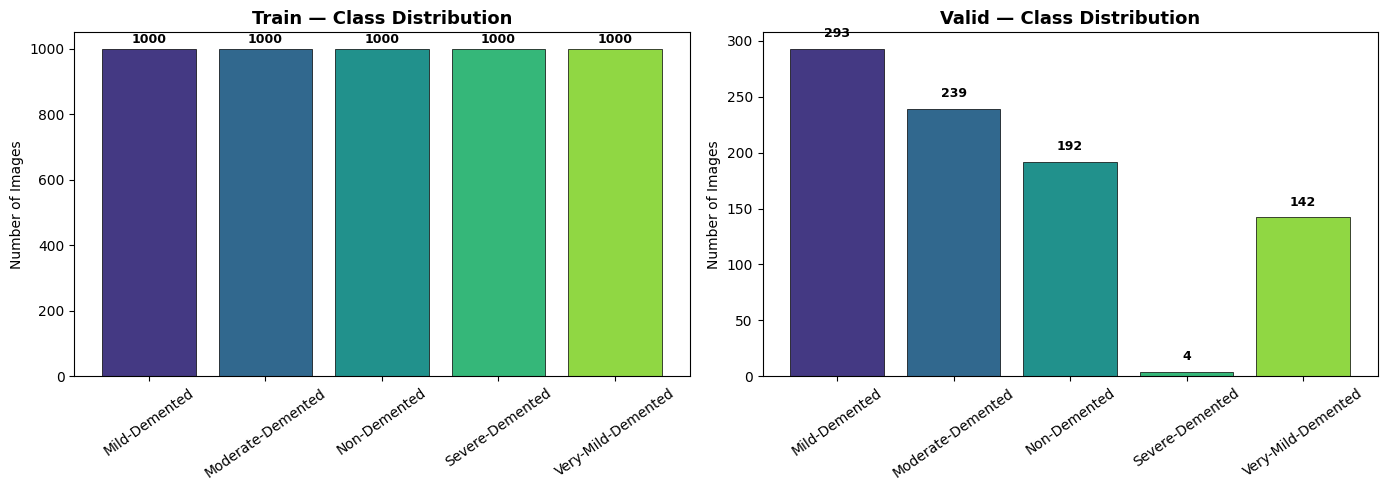

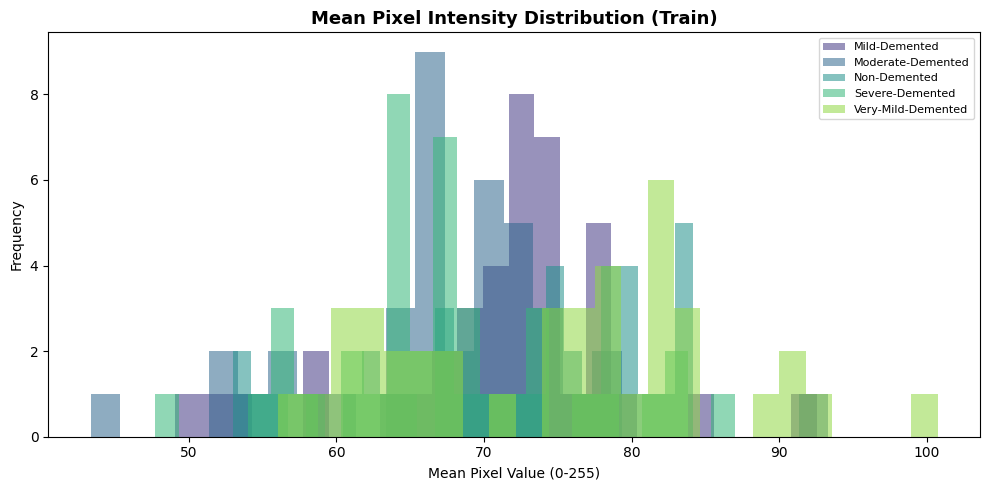

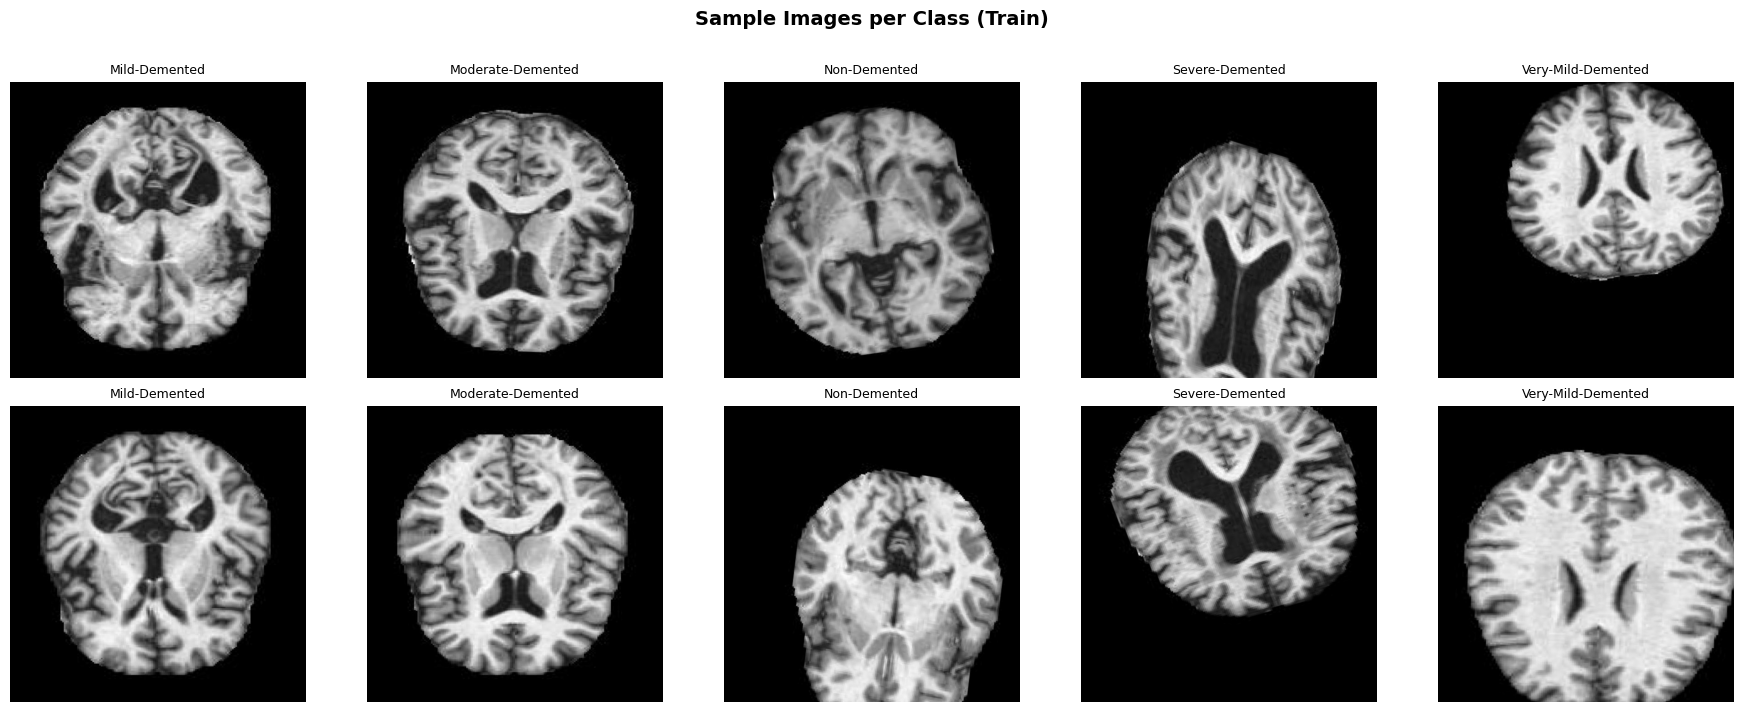


════════════════════════════════════════════════════════════════════════
  STAGE 3 — DATA LOADING
════════════════════════════════════════════════════════════════════════
Found 5000 images belonging to 5 classes.
Found 870 images belonging to 5 classes.
  Train batches/epoch : 157
  Valid batches/epoch : 28
  Class indices       : {'Mild-Demented': 0, 'Moderate-Demented': 1, 'Non-Demented': 2, 'Severe-Demented': 3, 'Very-Mild-Demented': 4}

════════════════════════════════════════════════════════════════════════
  BUILDING MODEL: InceptionResNetV2
════════════════════════════════════════════════════════════════════════
219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "InceptionResNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 111, 111,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 111, 111,  │         96 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 109, 109,  │      9,216 │ activation_94[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 109, 109,  │     18,432 │ activation_95[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 54, 54,    │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 54, 54,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 52, 52,    │    138,240 │ activation_97[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 55,132,389 (210.31 MB)

 Trainable params: 792,581 (3.02 MB)

 Non-trainable params: 54,339,808 (207.29 MB)


════════════════════════════════════════════════════════════════════════
  STAGE 5 — TRAINING
════════════════════════════════════════════════════════════════════════
  Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}
  Optimizer : AdamW (lr=0.001, wd=0.0005)
  Loss      : CCE (label_smoothing=0.1)
  Epochs    : 20 (max), Batch: 32
Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.7425 - loss: 1.3578
Epoch 1: val_loss improved from None to 0.91813, saving model to /content/drive/MyDrive/OUTPUT/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/OUTPUT/best_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 1934s 12s/step - accuracy: 0.7804 - loss: 1.2270 - val_accuracy: 0.7632 - val_loss: 0.9181 - learning_rate: 0.0010
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.8524 - loss: 0.8826
Epoch 2: val_loss improved from 0.91813 to 0.70609, saving model to /content/drive/MyD

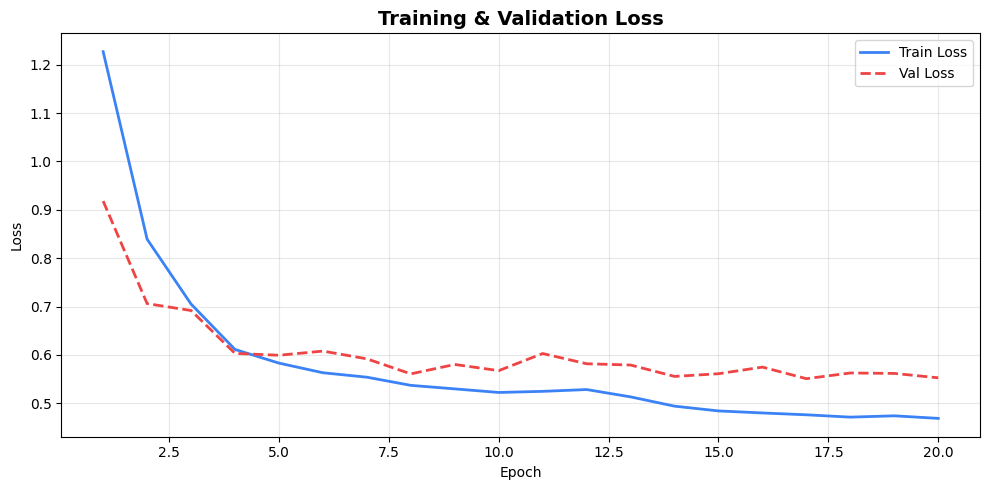

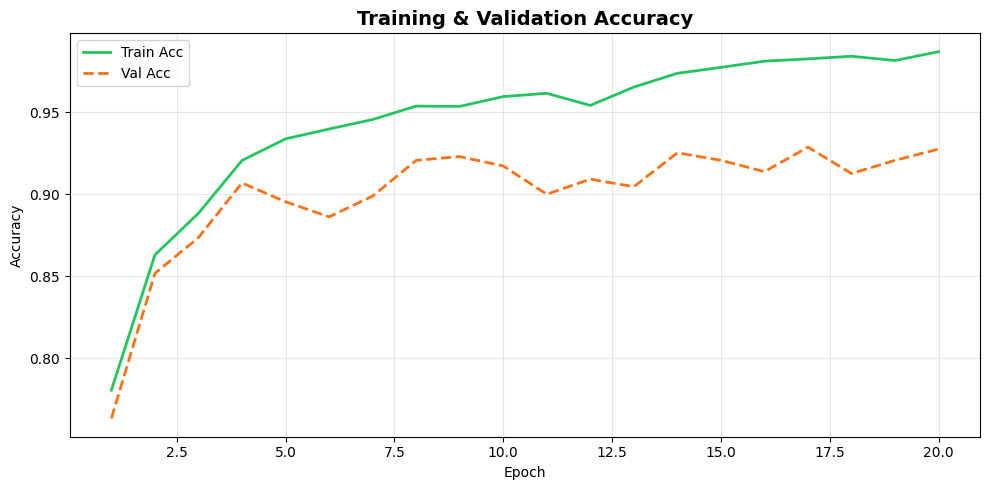

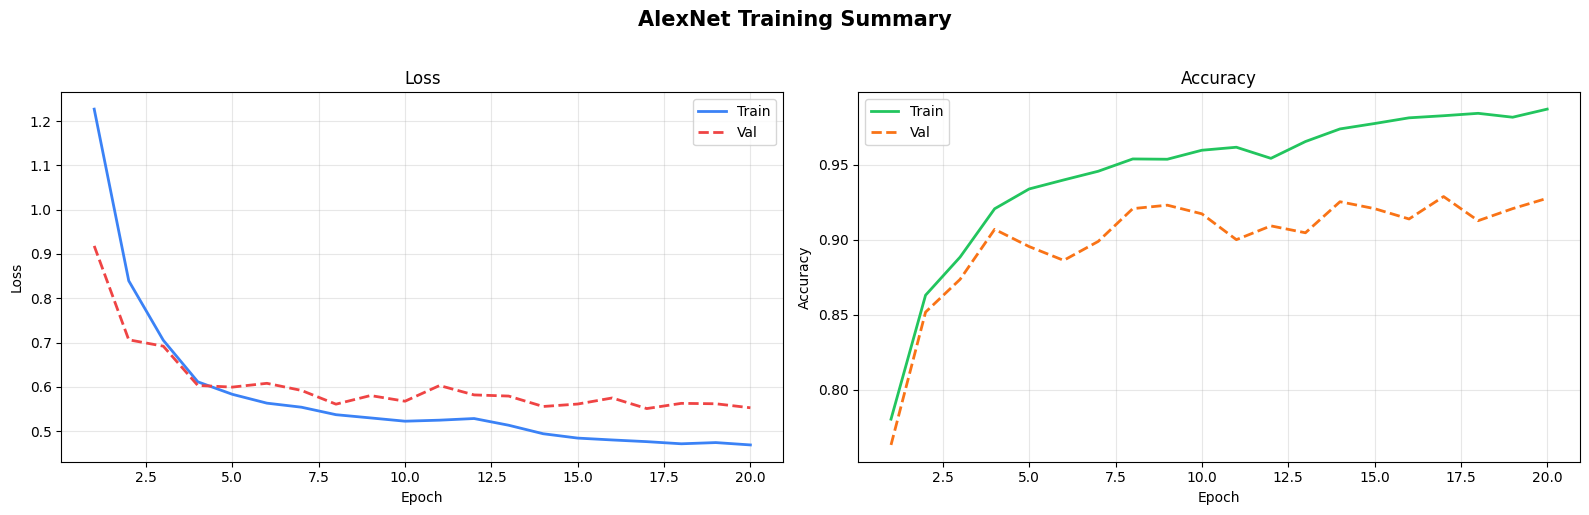

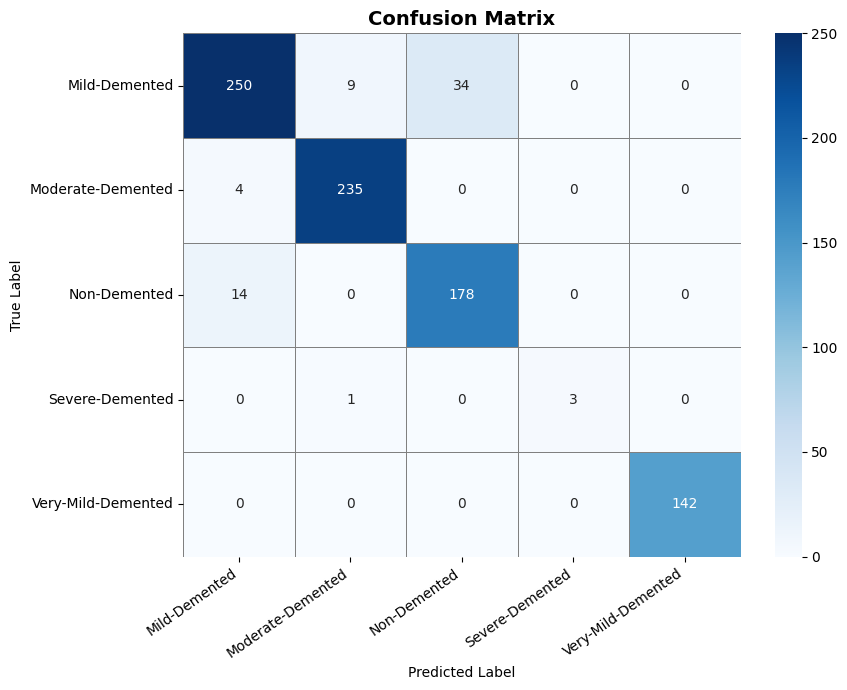

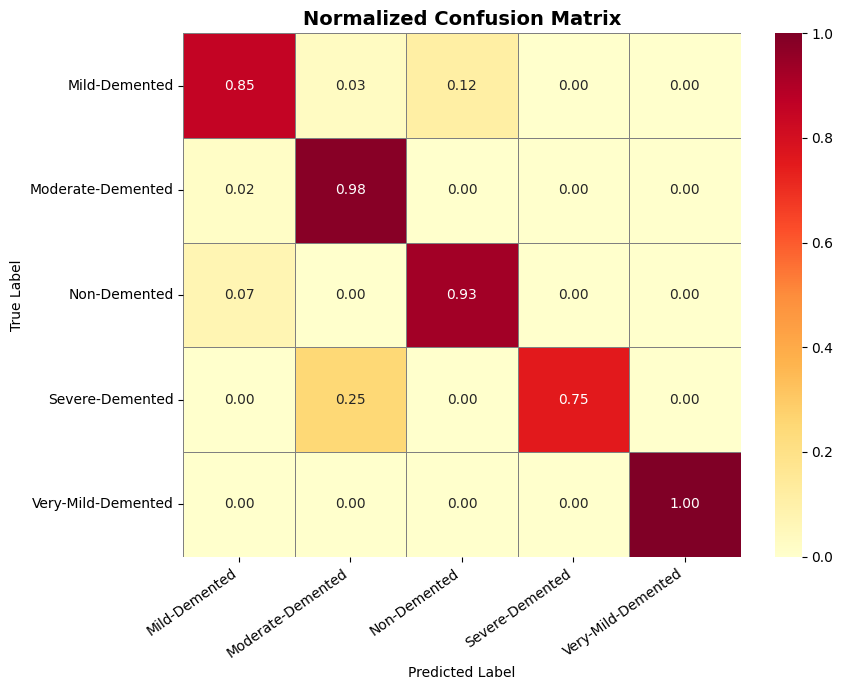


══════════════════════════════
InceptionResNetV2 Accuracy: 92.87%
══════════════════════════════


In [17]:
# cell 14
main("InceptionResNetV2")

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 15 — LOAD TRAINED INCEPTION MODELS (RUN AFTER TRAINING)
# ══════════════════════════════════════════════════════════════

inception_v3 = tf.keras.models.load_model(f"{CONFIG['output_dir']}/InceptionV3.keras")
inception_resnet_v2 = tf.keras.models.load_model(f"{CONFIG['output_dir']}/InceptionResNetV2.keras")

print("✅ InceptionV3 and Inception-ResNet-V2 models loaded successfully")

print("✅ Models loaded successfully")

In [ ]:
# (Run after train all models on next day not run in training models)
#cell 16 (PREDICT SINGLE IMAGE)
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_image(model, img_path):
    img = image.load_img(img_path, target_size=CONFIG["image_size"])
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    class_idx = np.argmax(prediction)

    return CONFIG["class_names"][class_idx], prediction

# Example usage:
img_path = "/content/sample.jpg"  # change this
label, prob = predict_image(vgg16, img_path)

print("Prediction:", label)

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 15 — COMPARE INCEPTION / GOOGLENET MODELS (RUN AFTER LOADING)
# ══════════════════════════════════════════════════════════════

models = {
    "InceptionV3": inception_v3,
    "Inception-ResNet-V2": inception_resnet_v2,
}

print("\n📊 MODEL COMPARISON RESULTS:\n")

for name, model in models.items():
    loss, acc = model.evaluate(valid_gen, verbose=0)
    print(f"{name} → Accuracy: {acc*100:.2f}% | Loss: {loss:.4f}")

In [ ]:
#END